In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)
wait_times

array([4.89605698, 4.13408284, 5.07722625, 6.12763583, 4.01901595,
       4.01903565, 6.19505538, 5.22092167, 3.73663074, 4.95107205,
       3.74389877, 3.7411243 , 4.59035473, 2.00406371, 2.2300986 ,
       3.62525496, 3.08460266, 4.6770968 , 3.21037111, 2.60523556,
       6.05877852, 4.02906844, 4.38103385, 2.59030218, 3.64674073,
       4.43310711, 2.91880771, 4.75083762, 3.57923357, 3.9499675 ,
       3.57795207, 6.52273382, 4.28380333, 3.03074689, 5.28705389])

Null hypothesis is the claim, which is coffee shop says their average wait time is 4 minutes.

Alternative hypothesis is the saying that Null hypothesis is not fully correct and can be rejected, in this scenario, alternative hypothesis is waiting time different from 4 minutes

In [3]:
st.ttest_1samp(wait_times, popmean=4.0)

TtestResult(statistic=np.float64(0.7450545455494864), pvalue=np.float64(0.46135826637733657), df=np.int64(34))

t-statistic is ~0.745, p-value is ~0.461

at alpha=0.05, p-value is significantly greater than alpha, which leads us to conclude that we fail to reject H0.

There is not enough evidence to conclude that average wait time is different from 4 minutes

In [4]:
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)
print(group_a)
print(group_b)
print(group_a.mean())
print(group_b.mean())

[37.3498762  54.50636314 28.48395851 36.06176741 54.36233483 60.86159896
 54.05641937 50.61222061 48.38675565 34.25773612 43.3618695  46.47233475
 64.68546671 56.12341947 30.84351814 55.88900763 47.37901264 43.876936
 59.34011547 64.37199427 63.17536143 41.92938972 48.28945149 55.97516118
 63.70654153 46.24990915 49.77209228 38.72398031 37.64552051 61.75030987
 68.27488034 51.13587854 64.04239477 56.3396323  44.25856294 56.33674727
 70.4564388  51.57008753 70.77572387 20.56305875 61.86283005 53.04456482
 48.41191179 53.10112932 28.14917302 49.36393735 56.28535086 69.73472854
 45.78075738 42.29807677]
[49.97540139 69.81562965 61.60251554 49.58335715 64.18574406 58.35908569
 70.56102987 47.17125669 52.41272995 51.51048586 36.51079073 61.14568388
 60.65477381 57.07158839 53.71578013 37.18480961 51.11096548 52.20199677
 45.76811823 54.74200004 62.656712   83.40660262 59.44408938 60.60570547
 55.95775718 30.13720299 56.62880574 57.84322294 91.48538957 54.30694649
 61.22166279 56.51403522 40

Null hypothesis is two groups' means are nearly equal and new design has no effect on orders.

Alternative hypothesis is two groups' means are not equal and new design has negative or positive effect on orders.

In [5]:
print(st.levene(group_a, group_b))
print(group_a.var())
print(group_b.var())

LeveneResult(statistic=np.float64(0.1394706424159864), pvalue=np.float64(0.7096144854457804))
133.33890570314526
165.86864257371056


variance of group a is: ~133 /
variance of group b is: ~165

levene results are:
t-stat ~ 0.139 /
p-value ~ 0.709

In [6]:
st.ttest_ind(group_a, group_b, equal_var=False)

TtestResult(statistic=np.float64(-2.26051641411263), pvalue=np.float64(0.02602782865907216), df=np.float64(96.85517569021937))

Welch's t-test results are:



t-stat ~ -2.26

p-value ~ 0.02

although group B has a little bit greater order value than group A, the difference is not statistically significant; there is not enough evidence to conclude that the new design changes the overall average order value.

In [7]:
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)
print(before)
print(after)

[82.39947524 63.73397366 67.42350787 76.50813774 60.15308547 71.81967948
 80.45714203 57.14013412 71.47707087 72.07906235 76.25458297 60.10439431
 59.4363471  74.17553252 72.37587739 72.0039428  72.77158568 64.55980223
 71.85802958 72.34457979 64.28518866 84.92619609 73.79066337 60.46957202
 75.25242887 62.20254664 76.29667683 79.26876463 63.43454145 77.70700903]
[87.46337987 70.84427446 79.90747278 78.28119716 59.38440465 70.37210733
 79.37809061 59.75462558 76.18283074 76.46251635 83.39049922 63.16940377
 69.70401748 75.85224836 88.97672322 78.13227954 71.48579789 62.20533974
 77.27039165 74.22726586 70.85519113 90.29238421 76.4265188  59.23560343
 70.67819275 62.96997188 83.5786708  83.33923335 60.20584756 81.57291366]


we use two-tailed because we want to measure effect of a new tool, this tool can affect, both positively and negatively 

Null hypothesis is there is no difference before and after since applying new workflow tool in company

Alternative hypothesis is there is a positive and negative difference before and after since applying new workflow tool in company


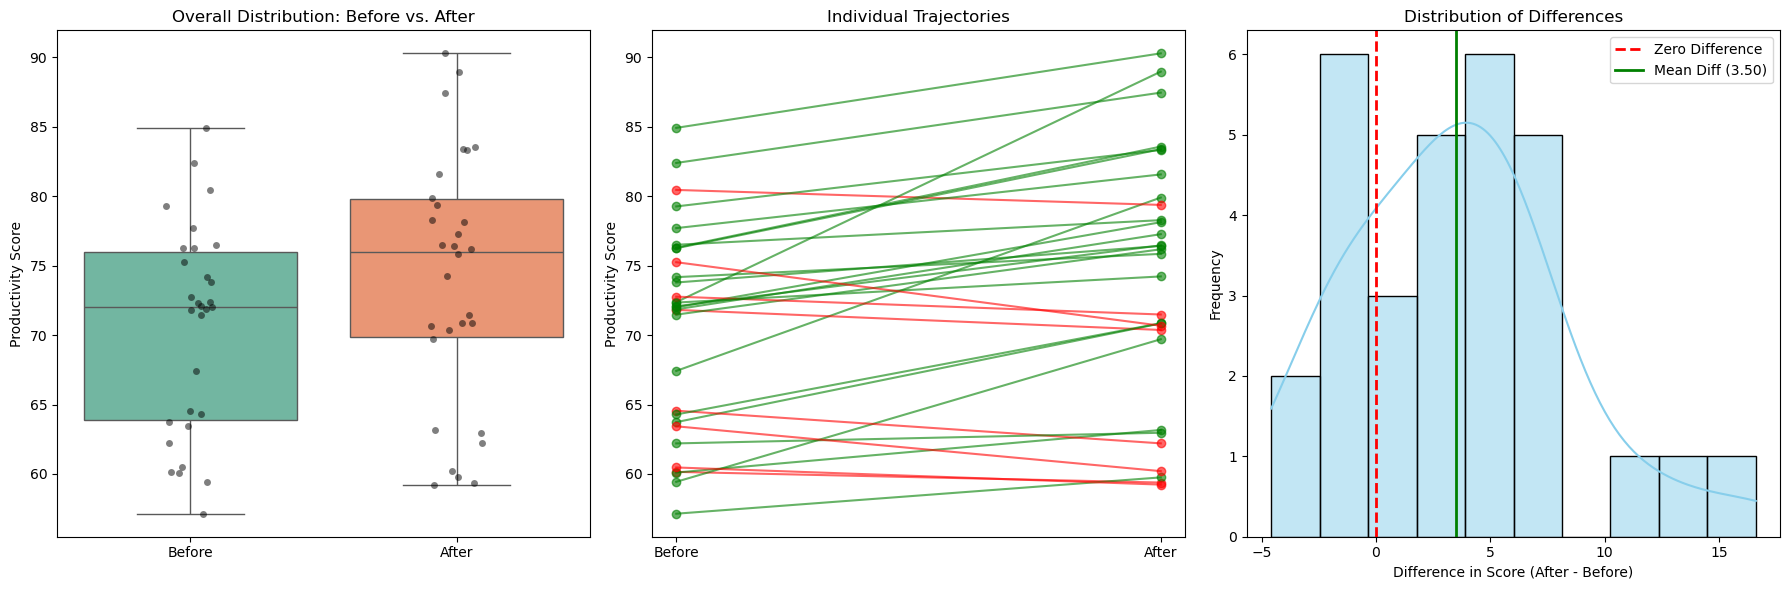

In [8]:
differences = after - before

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(data=[before, after], ax=axes[0], palette="Set2")
sns.stripplot(data=[before, after], ax=axes[0], color='black', alpha=0.5, jitter=True)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Before', 'After'])
axes[0].set_ylabel('Productivity Score')
axes[0].set_title('Overall Distribution: Before vs. After')

x_coords = [0, 1]
for i in range(len(before)):
    color = 'green' if after[i] > before[i] else 'red'
    axes[1].plot(x_coords, [before[i], after[i]], marker='o', color=color, alpha=0.6)
    
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Before', 'After'])
axes[1].set_ylabel('Productivity Score')
axes[1].set_title('Individual Trajectories')

sns.histplot(differences, bins=10, kde=True, ax=axes[2], color='skyblue')
axes[2].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Difference')
axes[2].axvline(np.mean(differences), color='green', linestyle='-', linewidth=2, label=f'Mean Diff ({np.mean(differences):.2f})')
axes[2].set_xlabel('Difference in Score (After - Before)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Differences')
axes[2].legend()

plt.tight_layout()

In [9]:
st.ttest_rel(after, before)

TtestResult(statistic=np.float64(4.079159168339153), pvalue=np.float64(0.0003225522319843029), df=np.int64(29))

t-stat is ~ 4.07

p-value ~ 0.0003

As we can see from p-value, t-stats and graphs, we can easily reject the null hypothesis. as an addition, new workflow tool has positive effect on productivity